<a href="https://colab.research.google.com/github/okparajoyf-cell/Computer-Vision-labs/blob/main/MIT8311_Lab1_Image_Processing_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Image Processing Fundamentals
Detecting the digit "1" in MNIST using thresholding and a hand-written rule.

# Lab 1: Image Processing Fundamentals
Detecting the digit "1" in MNIST using thresholding and a hand-written rule.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)  # (60000, 28, 28)

(60000, 28, 28)


In [ ]:
def binarize(img, t=127):
    _, b = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    return b

In [ ]:
def is_one(img, cutoff=100):
    b = binarize(img)
    score = b[:, 13:16].mean()
    return score > cutoff, score

Label 1 -> score 51.6 -> detected as 1: False


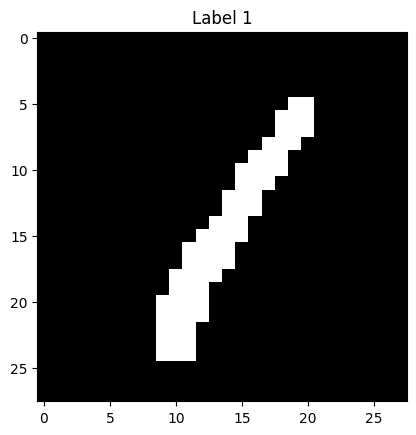

Label 5 -> score 88.0 -> detected as 1: False


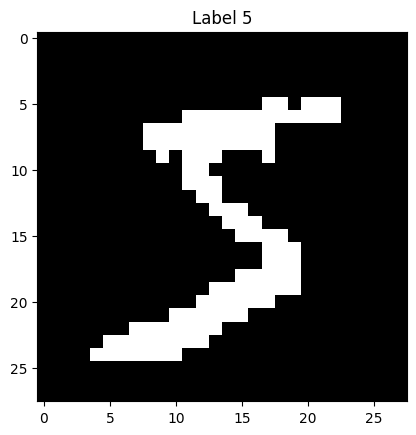

Label 0 -> score 60.7 -> detected as 1: False


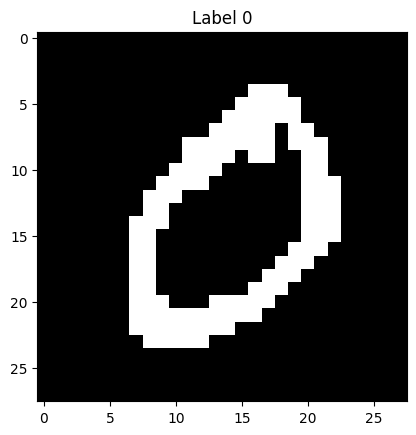

In [ ]:
for i in [3, 0, 1]:
    img = x_train[i]
    result, score = is_one(img)
    print(f"Label {y_train[i]} -> score {score:.1f} -> detected as 1: {result}")
    plt.imshow(binarize(img), cmap="gray")
    plt.title(f"Label {y_train[i]}")
    plt.show()

In [ ]:
for i in [3, 0, 1]:
    _, score = is_one(x_train[i], cutoff=0)
    print(f"Label {y_train[i]} -> score {score:.1f}")

Label 1 -> score 51.6
Label 5 -> score 88.0
Label 0 -> score 60.7


Best index: 174 Score: 182.1


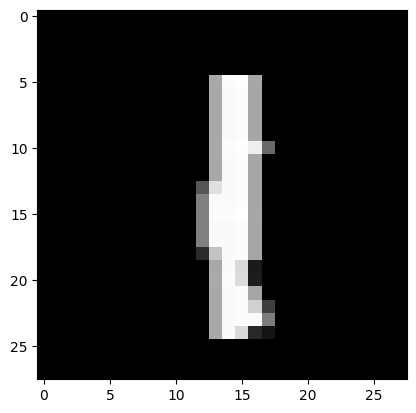

In [ ]:
ones = x_train[y_train == 1]
scores = [is_one(img, cutoff=0)[1] for img in ones[:200]]
best = int(np.argmax(scores))
print("Best index:", best, "Score:", round(scores[best], 1))
plt.imshow(ones[best], cmap="gray")
plt.show()

In [ ]:
clean_one = ones[best]
cutoff = 120  # change to your number

for name, img in [("1", clean_one), ("5", x_train[0]), ("0", x_train[1])]:
    result, score = is_one(img, cutoff)
    print(f"Digit {name} -> score {score:.1f} -> detected as 1: {result}")

Digit 1 -> score 182.1 -> detected as 1: True
Digit 5 -> score 88.0 -> detected as 1: False
Digit 0 -> score 60.7 -> detected as 1: False


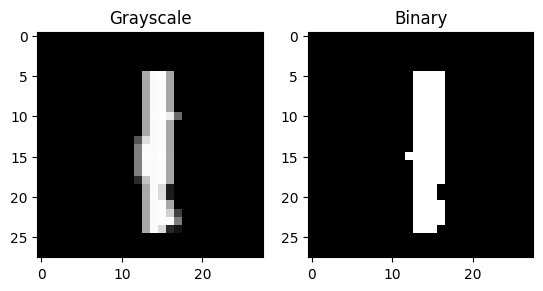

In [ ]:
img = clean_one
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap="gray"); ax[0].set_title("Grayscale")
ax[1].imshow(binarize(img), cmap="gray"); ax[1].set_title("Binary")
plt.show()

## My Observation
The detector accepted a clean "1" and rejected "5" and "0". But it is brittle. My first "1" was slanted and scored 51.6, lower than the "5" (88.0) and "0" (60.7), so the rule failed. A hand-written rule breaks when the writing changes a little. This is why Module 2 uses machine learning, so the computer can learn the pattern by itself.

# Lab 1: Image Processing Fundamentals
Detecting the digit "1" in MNIST using thresholding and a hand-written rule.